In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/search_interactions_clean.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Rows: 50000
Columns: 14


,event_id,user_id,session_id,query_text,timestamp,result_position,clicked,dwell_time_seconds,num_results_viewed,query_reformulated,session_duration,country,device_type,is_suspicious
0,E000001,U00861,S00838,mathematics,2026-01-01 00:00:00,4,0,9.80,2,0,349,india,india,0
1,E000002,U03773,S01893,statistics tutorial,2026-01-01 00:10:00,2,0,165.02,1,0,418,india,india,0
2,E000003,U03093,S01389,data analytics,2026-01-01 00:20:00,9,1,39.43,8,0,599,UK,UK,0
3,E000004,U00467,S07166,python tutorial,2026-01-01 00:30:00,9,0,59.33,10,0,371,india,india,0
4,E000005,U04427,S10134,machine learning,2026-01-01 00:40:00,2,1,75.18,2,1,887,india,india,0


In [ ]:
summary = df.groupby("is_suspicious").agg(
    total_events=("event_id", "count"),
    click_rate=("clicked", "mean"),
    avg_dwell_time=("dwell_time_seconds", "mean"),
    avg_results_viewed=("num_results_viewed", "mean"),
    reformulation_rate=("query_reformulated", "mean")
)

summary

,total_events,click_rate,avg_dwell_time,avg_results_viewed,reformulation_rate
is_suspicious,,,,,
0,46078,0.551304,60.095042,5.483376,0.178567
1,3922,0.546405,7.969159,1.492606,0.631820


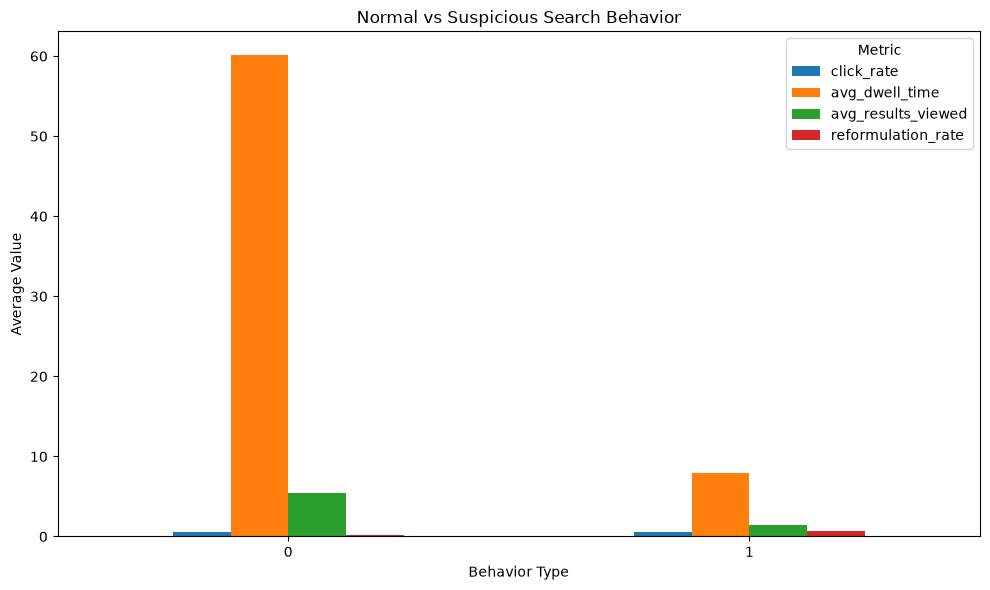

In [4]:
metrics = [
    "click_rate",
    "avg_dwell_time",
    "avg_results_viewed",
    "reformulation_rate"
]

summary[metrics].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Normal vs Suspicious Search Behavior")
plt.xlabel("Behavior Type")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()